In [ ]:
# Import library
import tensorflow as tf # TensorFlow: build and train a model
print("TensorFlow version:", tf.__version__)

import numpy as np #numerical operations
import matplotlib.pyplot as plt #visualize img and graphics
import os #folders
# Metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, auc, roc_curve
#to use modelcheckpoint
from keras.callbacks import ModelCheckpoint
#others:
import pandas as pd

import keras
from keras import layers #to create layers of the model
print(keras.__version__)

import seaborn as sns
import json
import shutil

import sklearn
print(sklearn.__version__)

#others for opt
from keras.regularizers import l2
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau

TensorFlow version: 2.20.0
3.13.2
1.6.1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#create folder structure for results history
BASE_PATH = "/content/drive/MyDrive/resultsVgg16DensenetOPT1"
print(BASE_PATH) #if the path is correct

folders = [
    "models",
    "histories",
    "metrics",
    "plots/training",
    "plots/confusion_matrix",
    "plots/roc"
]

for f in folders:
    os.makedirs(os.path.join(BASE_PATH, f), exist_ok=True)


#check dirive si correctly implemented
print(os.listdir("/content/drive/MyDrive"))
#check the path
print(os.listdir(BASE_PATH)) #if it exists

/content/drive/MyDrive/resultsVgg16DensenetOPT1
['Colab Notebooks', 'kaggle', 'results5', 'results10', 'resultsResnetOPT1', 'resultsVgg16DensenetOPT1', 'GradCam']
['models', 'histories', 'metrics', 'plots']


In [ ]:
# dataset folders directions
TRAIN_DIR = "/content/drive/MyDrive/kaggle/train"
TEST_DIR  = "/content/drive/MyDrive/kaggle/test"


#upload dataset

#define img sizes and batch sizes
IMG_SIZE = (224, 224)
BATCH_SIZE = 32 # 32= small batch ->indirectly helps against ovefitting

#train dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",          # takes labels from folders
    label_mode="binary",        # binary classification
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)
#test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

#check labels
class_names = train_ds.class_names
print("Class:", class_names)

Found 2637 files belonging to 2 classes.
Found 660 files belonging to 2 classes.
Class: ['benign', 'malignant']


Normalization & data augmentation

In [ ]:
#normalization to put all value in [0,1]
normalization_layer = layers.Rescaling(1./255)

#apply normalization to train and test dataset
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))



# fz for data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2) #OPT. randomzoom stronger: 0.1 -> 0.2
])

#apply data augm
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

#fz early stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

#fz reduce learning rate
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

CREATE VALIDATION DATASET (from training dataset)

In [ ]:
#split validation = 20% of train dataset
train_size = int(0.8 * tf.data.experimental.cardinality(train_ds).numpy()) #define size of train = 0,8 of the tot train_img

train_ds_split = train_ds.take(train_size) #new train dataset= 0,8 original train dataset
val_ds_split   = train_ds.skip(train_size) #validation dataset= 0,2 original train dataset

BUILD MODEL:
1) takes a CNN pre-trained (vg16, ResNet, DenseNet)
2) removes the original classificator of the model
3) block weight pre-trained
4) add a new classificator and adapt the algoritm to binary problem (benign vs melanoma malignant)


In [ ]:
#build model
def build_model(model_name):

    if model_name == "vgg16": #famous CNN: easy but powerful
        base_model = keras.applications.VGG16(
            weights="imagenet", #uses weight already trained on millions images
            include_top=False, #delate the last layer of clasification
            input_shape=(224,224,3) #img 224*224 RGB (3 colors)
        )

    elif model_name == "resnet": #resnet uses skip connection (deeper)
        base_model = keras.applications.ResNet50(
            weights="imagenet",
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "densenet": #more advanced: every layer connected to the following
        base_model = keras.applications.DenseNet121(
            weights="imagenet",
            include_top=False,
            input_shape=(224,224,3)
        )

    # Transfer learning (freeze of the firsts layers already trained)
    base_model.trainable = False

    #define of the imput imgs shapes: 224x224, RGB (3 colors)
    inputs = keras.Input(shape=(224,224,3))

    # oss. 'x' represent the input data in the model that changes step by step during the different passages of the model

    #!! IN THE PREVIOUS VERSION I APPLIED DATA AUG. HERE IN THE MODEL, BUT THIS CREATES PROBLEM IN SAVING THE MODEL

    x = base_model(inputs, training=False) #  l'immagine passa attraverso i modelli: vgg16/DenseNet/ResNet
    #training=false: use fix weights
    #training=true: update weights

    x = layers.GlobalAveragePooling2D()(x) #pooling layer: from 2D matrix to vector 512

    #OPT. L2 weight regularization
    x = layers.Dense(128, activation="relu", kernel_regularizer=l2(0.001))(x)

    #OPT. BATCH NORMALIZATION: stabilizza gradienti, taining e convergenza
    x = layers.BatchNormalization()(x)

    #OPT. increase dropout: 0.5 -> 0.6
    x = layers.Dropout(0.6)(x) #to avoid overfitting

    outputs = layers.Dense(1, activation="sigmoid")(x) #sigmoid gives probability output [0,1]
    # ouput 0=benign, 1=melanoma malignant

    #build the funcion model that takes the imgs input and gives a probability of a class as an output
    model = keras.Model(inputs, outputs) #imput ->network(layer->layer->layer->) -> output

    #optimizer
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    #return model ready for training
    return model


TRAINING:
create a for cicle to train and compare Vgg16 and DenseNet models in the same run.

Each cicle:
new model,
initial weights form ImageNet,
same final structure for all 3.

In [ ]:
EPOCHS = 10

history_dict = {}
results = {}

for name in ["vgg16", "densenet"]:
    print(f"\nTraining {name}")

    model = build_model(name) #create the model: output= probability benign vs malignant

    # create folders on drive
    os.makedirs(os.path.join(BASE_PATH, "models"), exist_ok=True) #exist_ok=true: doesn't crush if folder already exists
    os.makedirs(os.path.join(BASE_PATH, "histories"), exist_ok=True)

    #chekpoint_path
    checkpoint_path = os.path.join(BASE_PATH, "models", f"{name}_best.keras")

    # checkpoint (salva solo il migliore modello)
    #oss. salva il modello solo quando la val_loss migliora, altrimenti potrei salvare anche se va in overfitting :/
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path, #where it save the model
        monitor="val_loss", #check loss of validation
        save_best_only=True, #saves only if it gets better
        mode="min",
        verbose=1 #stamp when saves
    )

    #TRAINING

    history = model.fit(
      train_ds_split,
      validation_data=val_ds_split,
      epochs=EPOCHS,

      #OPT. early stopping & reduce learning rate
      callbacks=[checkpoint, early_stopping, reduce_lr] #activate fz in []
    )
    #SAVE HISTORY
    history_path = os.path.join(BASE_PATH, "histories", f"{name}_history.json") #history path

    with open(history_path, "w") as f:
        json.dump(history.history, f, indent=4) #saves history on files:
                                                #vgg16_history.json,resnet_history.json, densenet_history.json
    #oss. in histoy.histoy there are: {"loss": [...],"accuracy": [...], "val_loss": [...], "val_accuracy": [...]}

    history_dict[name] = history.history # store in dictionary (useful for quick plotting)



Training vgg16
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.7261 - loss: 0.7425 
Epoch 1: val_loss improved from None to 0.95341, saving model to /content/drive/MyDrive/resultsVgg16DensenetOPT1/models/vgg16_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/resultsVgg16DensenetOPT1/models/vgg16_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 1807s 27s/step - accuracy: 0.7685 - loss: 0.6369 - val_accuracy: 0.4362 - val_loss: 0.9534 - learning_rate: 0.0010
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.7889 - loss: 0.5554 
Epoch 2: val_loss improved from 0.95341 to 0.74065, saving model to /content/drive/MyDrive/resultsVgg16DensenetOPT1/models/vgg16_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/resultsVgg16DensenetOPT1/models/vgg16_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 1720s 26s/step - accuracy: 0.7902 - loss: 0.5470 - val_accuracy: 0.4705 - val_loss: 0.7406 - learning_r

In [ ]:
#train solo di densenet pk prima non aveva finito il training
EPOCHS = 10

history_dict = {}
results = {}

for name in ["densenet"]:
    print(f"\nTraining {name}")

    model = build_model(name) #create the model: output= probability benign vs malignant

    # create folders on drive
    os.makedirs(os.path.join(BASE_PATH, "models"), exist_ok=True) #exist_ok=true: doesn't crush if folder already exists
    os.makedirs(os.path.join(BASE_PATH, "histories"), exist_ok=True)

    #chekpoint_path
    checkpoint_path = os.path.join(BASE_PATH, "models", f"{name}_best.keras")

    # checkpoint (salva solo il migliore modello)
    #oss. salva il modello solo quando la val_loss migliora, altrimenti potrei salvare anche se va in overfitting :/
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path, #where it save the model
        monitor="val_loss", #check loss of validation
        save_best_only=True, #saves only if it gets better
        mode="min",
        verbose=1 #stamp when saves
    )

    #TRAINING

    history = model.fit(
      train_ds_split,
      validation_data=val_ds_split,
      epochs=EPOCHS,

      #OPT. early stopping & reduce learning rate
      callbacks=[checkpoint, early_stopping, reduce_lr] #activate fz in []
    )
    #SAVE HISTORY
    history_path = os.path.join(BASE_PATH, "histories", f"{name}_history.json") #history path

    with open(history_path, "w") as f:
        json.dump(history.history, f, indent=4) #saves history on files:
                                                #vgg16_history.json,resnet_history.json, densenet_history.json
    #oss. in histoy.histoy there are: {"loss": [...],"accuracy": [...], "val_loss": [...], "val_accuracy": [...]}

    history_dict[name] = history.history # store in dictionary (useful for quick plotting)


Training densenet
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6985 - loss: 0.8594
Epoch 1: val_loss improved from None to 0.52681, saving model to /content/drive/MyDrive/resultsVgg16DensenetOPT1/models/densenet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/resultsVgg16DensenetOPT1/models/densenet_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 539s 8s/step - accuracy: 0.7633 - loss: 0.6910 - val_accuracy: 0.8381 - val_loss: 0.5268 - learning_rate: 0.0010
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7976 - loss: 0.5874
Epoch 2: val_loss improved from 0.52681 to 0.48881, saving model to /content/drive/MyDrive/resultsVgg16DensenetOPT1/models/densenet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/resultsVgg16DensenetOPT1/models/densenet_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 484s 7s/step - accuracy: 0.8111 - loss: 0.5499 - val_accuracy: 0.8419 - val_loss: 0.4888 - lea

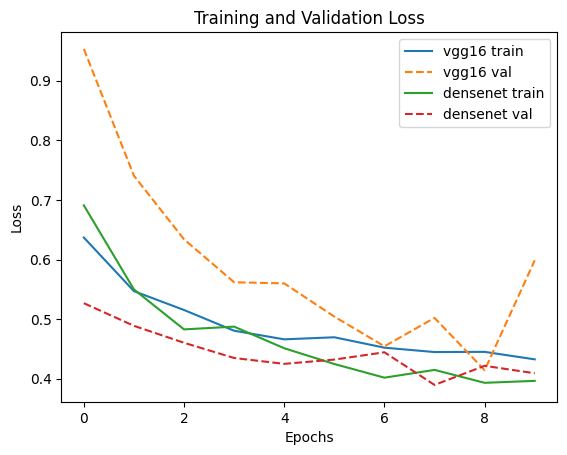

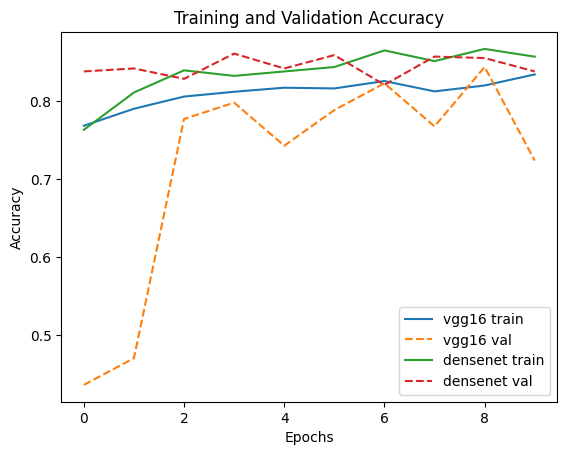

In [ ]:
models = ["vgg16", "densenet"]
history_dict = {} #dictionary where i save all the historys

# load history from drive
for name in models:
    history_path = os.path.join(BASE_PATH, "histories", f"{name}_history.json") #build file path

#open file json, read it, convert it in python, save it in history_dict
    with open(history_path, "r") as f:
        history_dict[name] = json.load(f)


#PLOT LOSS
plt.figure() #create a new empty figure

for name in models:
    plt.plot(history_dict[name]["loss"], label=f"{name} train") #training loss: solid line
    plt.plot(history_dict[name]["val_loss"], linestyle="--", label=f"{name} val") #validation loss: dashed line

plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

#save in drive
loss_plot_path = os.path.join(BASE_PATH, "plots", "training", "loss_plot.png") #create path on drive
plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight") #savefig: save graphic, dpi=300: high quality, "tight" delete empty points

plt.show() #show graphic
 #train loss ↓ =the model is learning
 # val loss ↓ = model generalise correctly
 #val loss ↑ while tain loss ↓ = overfitting


#ACCURACY PLOT
plt.figure()

for name in models:
    plt.plot(history_dict[name]["accuracy"], label=f"{name} train")
    plt.plot(history_dict[name]["val_accuracy"], linestyle="--", label=f"{name} val")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

#save in drive
acc_plot_path = os.path.join(BASE_PATH, "plots", "training", "accuracy_plot.png") #create path on drive
plt.savefig(acc_plot_path, dpi=300, bbox_inches="tight")

plt.show()
#accuracy ↑ = model is getting better
#gap train vs val = overfitting
#similar graphic curves = good generalization

TEST

In [ ]:
#build funcion model evaluate:
def evaluate_model(model, dataset):

    y_true = []
    y_pred = []

    # iterate over test dataset
    for x, y in dataset: #x=img, y=real label
        preds = model(x, training=False).numpy() #gives probability. training=false:no training
        #build lists:
        y_true.extend(y.numpy()) #true value
        y_pred.extend(preds.flatten()) #prediction

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # build the binary classification based on probability
    # threshold 0.5: <=0.5 benign
    y_bin = (y_pred > 0.5).astype(int)

    # confusion matrix
    cm = confusion_matrix(y_true, y_bin)
    tn, fp, fn, tp = cm.ravel()
    #TN= true negative at melanoma (true benign)
    #TP → true positive
    #FP → false positive at melanoma
    #FN → false negative (melanoma not diagnosticated!! most dangerous)

    # metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn) #how much the model is correct in general
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0 #!ability to find melanoma oss. if evida crash in edge cases
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0 ##ability to recognise benign
    f1 = 2 * tp / (2 * tp + fp + fn) #precision vs recall
    auc = roc_auc_score(y_true, y_pred)   # #global quality of the model. nb: use probabilities not classes

    return {
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1,
        "auc": auc
    }


# LOAD MODELS + TEST
models = ["vgg16", "densenet"]
results = {}

for name in models:
    print(f"\nTesting {name}")

    # LOAD best model saved by ModelCheckpoint
    model_path = os.path.join(BASE_PATH, "models", f"{name}_best.keras") #path only of the best model saved

    print(f"Attempting to load model from: {model_path}")

    model = keras.models.load_model(model_path) #load the best model in "model"

    # TEST: evaluate model
    metrics = evaluate_model(model, test_ds)
    results[name] = metrics #build the finally dictionary
    print(metrics)

# SAVE final results table
results_path = os.path.join(BASE_PATH, "metrics", "final_results.csv")

df = pd.DataFrame(results).T
df.to_csv(results_path) #saves the final tab: model | accuracy | sensitivity | specificity | f1 | auc

print("\nResults saved to:", results_path)


Testing vgg16
Attempting to load model from: /content/drive/MyDrive/resultsVgg16DensenetOPT1/models/vgg16_best.keras
{'accuracy': np.float64(0.8424242424242424), 'sensitivity': np.float64(0.88), 'specificity': np.float64(0.8111111111111111), 'f1': np.float64(0.8354430379746836), 'auc': np.float64(0.9191944444444444)}

Testing densenet
Attempting to load model from: /content/drive/MyDrive/resultsVgg16DensenetOPT1/models/densenet_best.keras
{'accuracy': np.float64(0.8560606060606061), 'sensitivity': np.float64(0.8833333333333333), 'specificity': np.float64(0.8333333333333334), 'f1': np.float64(0.848), 'auc': np.float64(0.9265555555555556)}

Results saved to: /content/drive/MyDrive/resultsVgg16DensenetOPT1/metrics/final_results.csv


PLOT METRICS to compare performance

          accuracy  sensitivity  specificity        f1       auc
vgg16     0.842424     0.880000     0.811111  0.835443  0.919194
densenet  0.856061     0.883333     0.833333  0.848000  0.926556


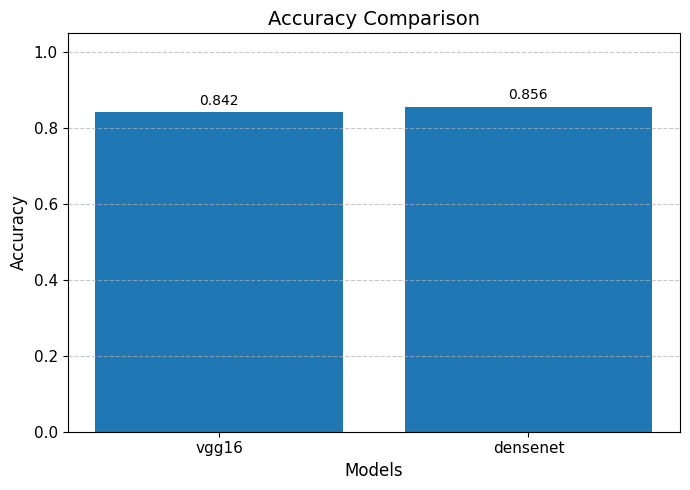

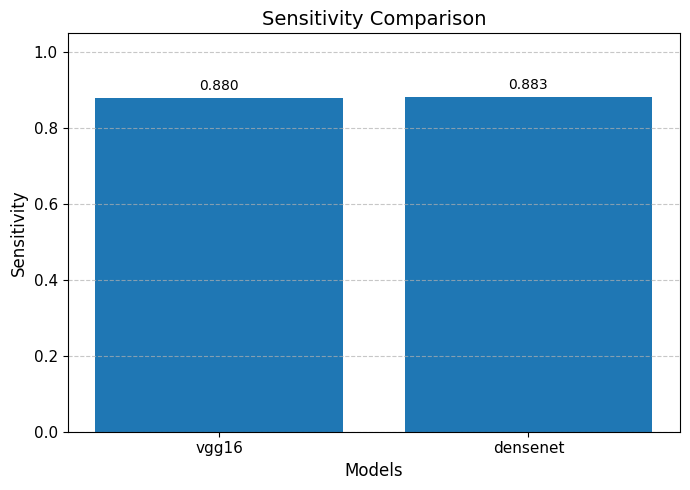

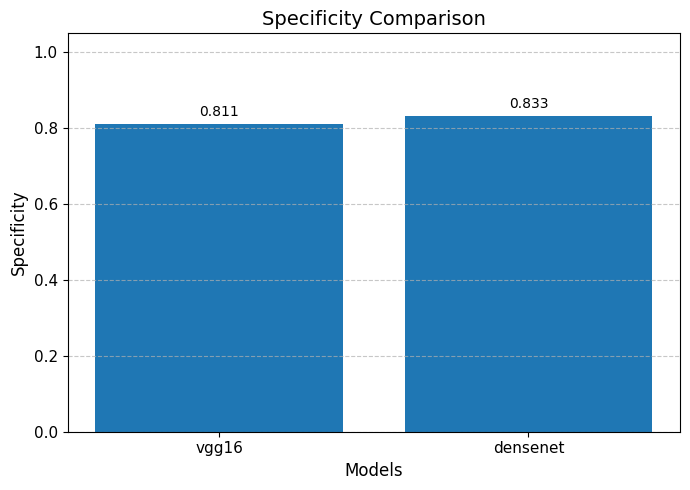

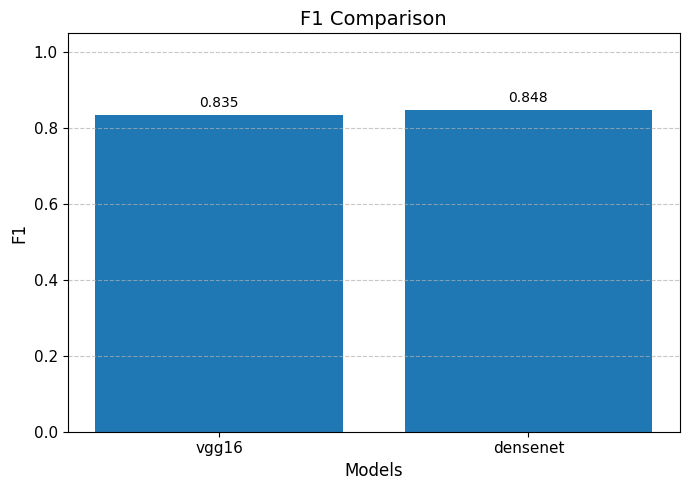

In [ ]:
# LOAD FINAL METRICS
results_path = os.path.join(BASE_PATH, "metrics", "final_results.csv")
df = pd.read_csv(results_path, index_col=0)
print(df)

# CREATE COMPARISON GRAPHS
metrics_list = ["accuracy", "sensitivity", "specificity", "f1"]
os.makedirs(os.path.join(BASE_PATH, "plots", "metrics"), exist_ok=True) #create path

for metric in metrics_list:

    # larger figure for thesis quality
    plt.figure(figsize=(7,5))

    # bar plot
    bars = plt.bar(df.index, df[metric])

    # titles and labels
    plt.title(f"{metric.capitalize()} Comparison", fontsize=14)
    plt.xlabel("Models", fontsize=12)
    plt.ylabel(metric.capitalize(), fontsize=12)

    # better axis scale
    plt.ylim(0, 1.05)

    # improve ticks
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)

    # values above bars
    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.02,
            f"{height:.3f}",
            ha="center",
            fontsize=10
        )

    # horizontal grid only
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # automatically fix layout problems
    plt.tight_layout()

    # save plot
    save_path = os.path.join(
        BASE_PATH,
        "plots",
        "metrics",
        f"{metric}_comparison.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()

ROC CURVE GRAPHIC (false positive vs sensitivity)


Generating ROC for vgg16


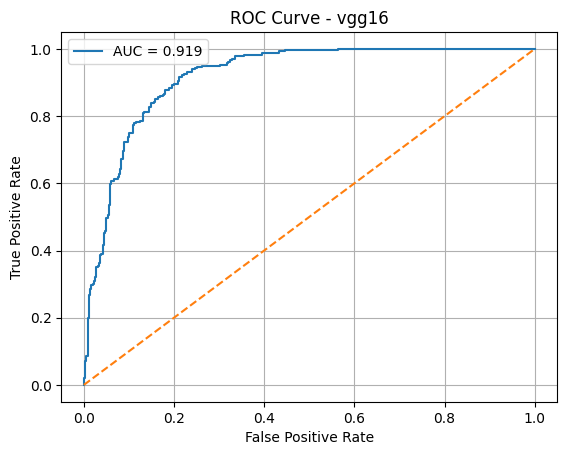


Generating ROC for densenet


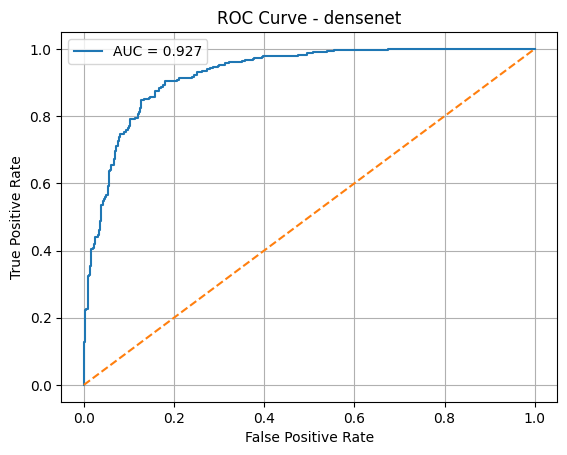

ROC data saved to: /content/drive/MyDrive/resultsVgg16DensenetOPT1/metrics/roc_data.json


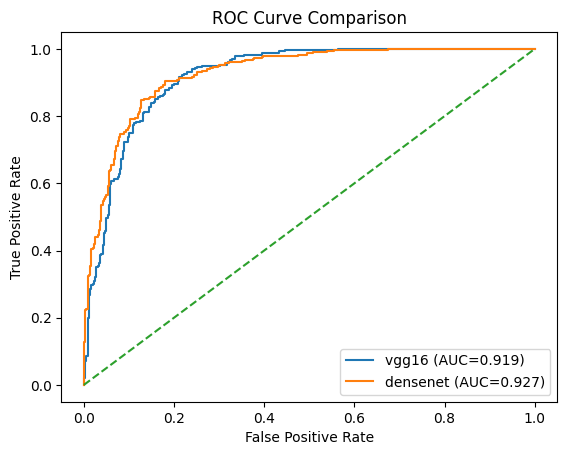

In [ ]:
# Diagonal line: causal model
# Line close to the left upper part: good model


#CREATE FUNCTION ROC CURVE that:
#takes model->test dataset-> create ROC-curve
def plot_roc(model, dataset, name):

    y_true = [] #real label
    y_pred = [] #probability

    # collect predictions
    for x, y in dataset:
        preds = model(x, training=False).numpy() #gives prbability [0,1]

        y_true.extend(y.numpy().flatten()) #list of true label
        y_pred.extend(preds.flatten()) #list of predictions

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # compute ROC
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr) #global metric: 1=perfect, 0.5=random, <0.5=terrible
    #FPR=False Positive Rate
    #TPR= True Positive Rate/sensibility

    # PLOT
    plt.figure()

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}") #roc curve
    plt.plot([0, 1], [0, 1], linestyle="--") #random baseline

    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True)
    plt.legend()

    # SAVE img
    save_path = os.path.join(BASE_PATH, "plots", "roc", f"{name}.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return fpr, tpr, roc_auc

# LOOP MODELS + SAVE DATA FOR COMPARISON
models = ["vgg16", "densenet"]
roc_data = {}

for name in models:
    print(f"\nGenerating ROC for {name}")

    model_path = os.path.join(BASE_PATH, "models", f"{name}_best.keras")
    model = keras.models.load_model(model_path)

    fpr, tpr, roc_auc = plot_roc(model, test_ds, name)

    roc_data[name] = { #raccolta dati per confronto
        "fpr": fpr.tolist(),   # impo conversation
        "tpr": tpr.tolist(),   # JSON dosen't support array numpy
        "auc": float(roc_auc)
    }

# SAVE ROC DATA
roc_data_path = os.path.join(BASE_PATH, "metrics", "roc_data.json")

with open(roc_data_path, "w") as f:
    json.dump(roc_data, f, indent=4)

print("ROC data saved to:", roc_data_path)


# COMPARISON PLOT (ALL MODELS)
plt.figure()

for name in models: #all curves in a single plot
    plt.plot(
        roc_data[name]["fpr"],
        roc_data[name]["tpr"],
        label=f"{name} (AUC={roc_data[name]['auc']:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

comparison_path = os.path.join(BASE_PATH, "plots", "roc", "roc_comparison.png")
plt.savefig(comparison_path, dpi=300, bbox_inches="tight")

plt.show()

CONFUSION MATRIX GRAPHIC


Generating Confusion Matrix for vgg16


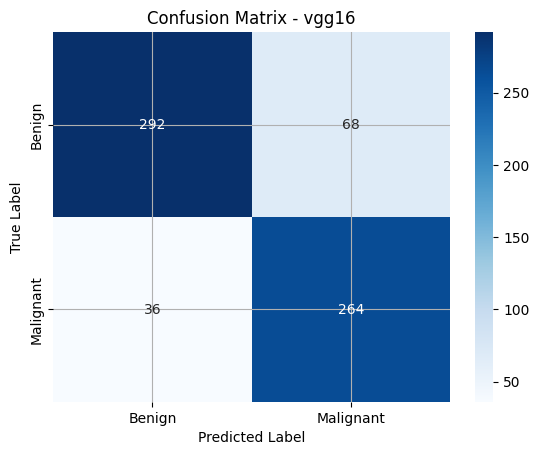


Generating Confusion Matrix for densenet


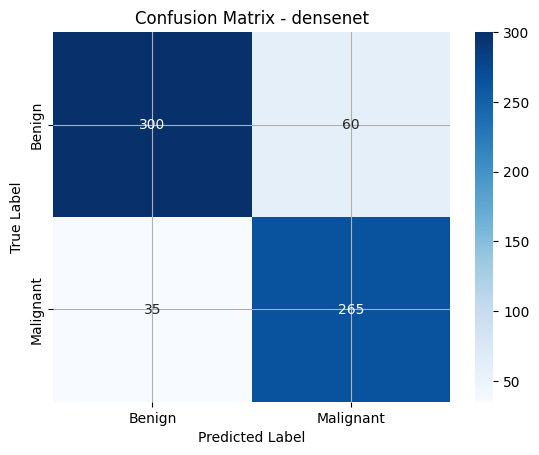

In [ ]:
#Confusion matrix graphic

#function for confusion matrix:
#take model->test>build confusion matrix->save it as img
def plot_cm(model, dataset, name):

    y_true = []
    y_pred = []

    # generate predictions
    for x, y in dataset: #x=img, y=true label
        preds = model(x, training=False).numpy() #give probability [0,1]

        y_true.extend(y.numpy()) #real label
        y_pred.extend(preds.flatten()) #probability

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # probability -> class predictionon
    y_bin = (y_pred > 0.5).astype(int)
    # confusion matrix (2x2 matrix)
    cm = confusion_matrix(y_true, y_bin)

    # PLOT
    plt.figure()

    sns.heatmap(
        cm,
        annot=True, #show numbers
        fmt="d", #formato intero
        cmap="Blues",#readables colors
        xticklabels=["Benign", "Malignant"],
        yticklabels=["Benign", "Malignant"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.grid(True)

    # SAVE to drive
    save_path = os.path.join(BASE_PATH, "plots", "confusion_matrix", f"{name}.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight") #300=high quality, "tight"=clean format

    plt.show()



# LOAD MODELS + CM
models = ["vgg16", "densenet"]

#for all models:
#load best model->CM->save in drive
for name in models:
    print(f"\nGenerating Confusion Matrix for {name}")

    # load best model
    model_path = os.path.join(BASE_PATH, "models", f"{name}_best.keras")
    model = keras.models.load_model(model_path)

    # plot confusion matrix
    plot_cm(model, test_ds, name)

Grad-CAM

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow import keras

#config
IMG_SIZE = (224, 224)
N_IMAGES_PER_CLASS = 10
THRESHOLD = 0.5

SAVE_ROOT = "/content/drive/MyDrive/GradCam/OPTvgg16andDensenet"
os.makedirs(SAVE_ROOT, exist_ok=True)

print("Saving Grad-CAM results to:", SAVE_ROOT)

#build flat model
def build_flat_model(model_name):
    inputs = keras.Input(shape=(224, 224, 3), name=f"{model_name}_input")

    if model_name == "vgg16":
        backbone = keras.applications.VGG16(
            weights="imagenet",
            include_top=False,
            input_tensor=inputs
        )
        last_conv_name = "block5_conv3"

    elif model_name == "densenet":
        backbone = keras.applications.DenseNet121(
            weights="imagenet",
            include_top=False,
            input_tensor=inputs
        )
        last_conv_name = "conv5_block16_2_conv"

    else:
        raise ValueError("model_name must be 'vgg16' or 'densenet'")

    x = backbone.output
    x = keras.layers.GlobalAveragePooling2D(name="head_gap")(x)
    x = keras.layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(0.001),
        name="head_dense"
    )(x)
    x = keras.layers.BatchNormalization(name="head_bn")(x)
    x = keras.layers.Dropout(0.6, name="head_dropout")(x)
    outputs = keras.layers.Dense(1, activation="sigmoid", name="head_output")(x)

    model = keras.Model(inputs, outputs, name=f"{model_name}_flat_model")
    return model, last_conv_name


# COPY TRAINED HEAD WEIGHTS:robusto per VGG16 e DenseNet

def load_trained_weights_into_flat_model(model_name, weights_path):
    flat_model, last_conv_name = build_flat_model(model_name)
    trained = keras.models.load_model(weights_path)

    trained_head_out = None
    trained_head_bn = None
    trained_head_dense = None

    for layer in reversed(trained.layers):
        if trained_head_out is None and isinstance(layer, keras.layers.Dense):
            trained_head_out = layer
            continue
        if trained_head_bn is None and isinstance(layer, keras.layers.BatchNormalization):
            trained_head_bn = layer
            continue
        if trained_head_dense is None and isinstance(layer, keras.layers.Dense):
            trained_head_dense = layer
            break

    if trained_head_dense is None or trained_head_bn is None or trained_head_out is None:
        raise RuntimeError(
            f"Could not identify trained head layers for model {model_name}"
        )

    flat_dense = flat_model.get_layer("head_dense")
    flat_bn = flat_model.get_layer("head_bn")
    flat_out = flat_model.get_layer("head_output")

    def same_shapes(layer_a, layer_b):
        wa = [w.shape for w in layer_a.get_weights()]
        wb = [w.shape for w in layer_b.get_weights()]
        return wa == wb

    if not same_shapes(trained_head_dense, flat_dense):
        raise RuntimeError(
            f"Dense shape mismatch for {model_name}: "
            f"trained={ [w.shape for w in trained_head_dense.get_weights()] } vs "
            f"flat={ [w.shape for w in flat_dense.get_weights()] }"
        )

    if not same_shapes(trained_head_bn, flat_bn):
        raise RuntimeError(
            f"BN shape mismatch for {model_name}: "
            f"trained={ [w.shape for w in trained_head_bn.get_weights()] } vs "
            f"flat={ [w.shape for w in flat_bn.get_weights()] }"
        )

    if not same_shapes(trained_head_out, flat_out):
        raise RuntimeError(
            f"Output shape mismatch for {model_name}: "
            f"trained={ [w.shape for w in trained_head_out.get_weights()] } vs "
            f"flat={ [w.shape for w in flat_out.get_weights()] }"
        )

    flat_dense.set_weights(trained_head_dense.get_weights())
    flat_bn.set_weights(trained_head_bn.get_weights())
    flat_out.set_weights(trained_head_out.get_weights())

    print(f"[OK] Copied classifier head weights for {model_name}")
    print(f"      trained dense: {trained_head_dense.name}")
    print(f"      trained bn   : {trained_head_bn.name}")
    print(f"      trained out  : {trained_head_out.name}")

    return flat_model, last_conv_name


# LOAD FIRST N IMAGES FROM CLASS
def load_first_n_from_class(test_dir, class_name, n=10):
    class_dir = os.path.join(test_dir, class_name)

    files = sorted([
        os.path.join(class_dir, f)
        for f in os.listdir(class_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])[:n]

    imgs = []
    for f in files:
        img = keras.utils.load_img(f, target_size=IMG_SIZE)
        img = keras.utils.img_to_array(img).astype("float32") / 255.0
        imgs.append((img, f))
    return imgs


# PREDICTION
def predict_binary(model, img, threshold=0.5):
    img_batch = np.expand_dims(img, axis=0).astype(np.float32)
    prob = float(model.predict(img_batch, verbose=0)[0][0])
    pred_label = 1 if prob > threshold else 0
    pred_class = "malignant" if pred_label == 1 else "benign"
    return prob, pred_label, pred_class

def get_outcome_label(true_class, pred_label):
    true_label = 1 if true_class == "malignant" else 0

    if true_label == 0 and pred_label == 0:
        return "TN"
    elif true_label == 0 and pred_label == 1:
        return "FP"
    elif true_label == 1 and pred_label == 0:
        return "FN"
    elif true_label == 1 and pred_label == 1:
        return "TP"
    else:
        raise ValueError("Unexpected true/pred combination")


# GRAD-CAM
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    if img_array.ndim == 3:
        img_array = np.expand_dims(img_array, axis=0)

    img_array = tf.convert_to_tensor(img_array, dtype=tf.float32)

    last_conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = keras.Model(
        model.inputs,
        [last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    if grads is None:
        raise RuntimeError(
            f"Gradients are None for {last_conv_layer_name} in model {model.name}"
        )

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

def overlay_heatmap(img, heatmap, alpha=0.4):
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        img.shape[:2]
    ).numpy().squeeze()

    heatmap_color = cm.get_cmap("jet")(heatmap_resized)[..., :3]
    overlay = np.clip((1 - alpha) * img + alpha * heatmap_color, 0, 1)

    return heatmap_resized, overlay


# SAVE FIGURES

def save_gradcam_panel(img, heatmap, overlay, save_path, title_text):
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))

    ax[0].imshow(img)
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(heatmap, cmap="jet")
    ax[1].set_title("Heatmap")
    ax[1].axis("off")

    ax[2].imshow(overlay)
    ax[2].set_title("Overlay")
    ax[2].axis("off")

    fig.suptitle(title_text, fontsize=11)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def save_single_outputs(img, heatmap, overlay, out_dir, base_name, title_text):
    os.makedirs(out_dir, exist_ok=True)

    original_path = os.path.join(out_dir, f"{base_name}_original.png")
    heatmap_path  = os.path.join(out_dir, f"{base_name}_heatmap.png")
    overlay_path  = os.path.join(out_dir, f"{base_name}_overlay.png")
    panel_path    = os.path.join(out_dir, f"{base_name}_panel.png")

    plt.imsave(original_path, img)
    plt.imsave(heatmap_path, heatmap, cmap="jet")
    plt.imsave(overlay_path, overlay)

    save_gradcam_panel(img, heatmap, overlay, panel_path, title_text)

    return original_path, heatmap_path, overlay_path, panel_path


# RUN FOR ONE MODEL

def run_gradcam_for_model(model_name, test_dir, save_root, n_per_class=10, threshold=0.5):
    model_path = os.path.join(BASE_PATH, "models", f"{model_name}_best.keras")
    model, last_conv_name = load_trained_weights_into_flat_model(model_name, model_path)

    rows = []

    for true_class in ["benign", "malignant"]:
        samples = load_first_n_from_class(test_dir, true_class, n=n_per_class)

        for i, (img, img_path) in enumerate(samples, start=1):
            prob, pred_label, pred_class = predict_binary(model, img, threshold=threshold)
            outcome = get_outcome_label(true_class, pred_label)

            heatmap = make_gradcam_heatmap(img, model, last_conv_name)
            heatmap_resized, overlay = overlay_heatmap(img, heatmap, alpha=0.4)

            out_dir = os.path.join(save_root, model_name, outcome, true_class)
            base_name = f"{true_class}_{i:02d}"

            title_text = (
                f"Model: {model_name.upper()} | True: {true_class} | "
                f"Pred: {pred_class} | Outcome: {outcome} | "
                f"P(malignant)={prob:.4f}"
            )

            original_path, heatmap_path, overlay_path, panel_path = save_single_outputs(
                img=img,
                heatmap=heatmap_resized,
                overlay=overlay,
                out_dir=out_dir,
                base_name=base_name,
                title_text=title_text
            )

            rows.append({
                "model": model_name,
                "true_class": true_class,
                "pred_class": pred_class,
                "pred_prob_malignant": prob,
                "pred_label": pred_label,
                "outcome": outcome,
                "sample_index": i,
                "filename": os.path.basename(img_path),
                "full_path": img_path,
                "last_conv_layer": last_conv_name,
                "original_path": original_path,
                "heatmap_path": heatmap_path,
                "overlay_path": overlay_path,
                "panel_path": panel_path
            })

    df = pd.DataFrame(rows)

    csv_path = os.path.join(save_root, f"{model_name}_gradcam_results.csv")
    df.to_csv(csv_path, index=False)

    summary_counts = df["outcome"].value_counts().to_dict()
    summary_df = pd.DataFrame([summary_counts]).fillna(0)
    summary_path = os.path.join(save_root, f"{model_name}_summary.csv")
    summary_df.to_csv(summary_path, index=False)

    return df, csv_path, summary_path


# RUN ALL
all_dfs = []

for model_name in ["vgg16", "densenet"]:
    print(f"\nRunning Grad-CAM for {model_name}...")
    df_model, csv_model, summary_model = run_gradcam_for_model(
        model_name=model_name,
        test_dir=TEST_DIR,
        save_root=SAVE_ROOT,
        n_per_class=N_IMAGES_PER_CLASS,
        threshold=THRESHOLD
    )

    all_dfs.append(df_model)

    print(f"Saved detailed CSV: {csv_model}")
    print(f"Saved summary CSV: {summary_model}")
    print(df_model[["model", "true_class", "pred_class", "outcome", "pred_prob_malignant"]].head())

merged_df = pd.concat(all_dfs, ignore_index=True)
merged_csv = os.path.join(SAVE_ROOT, "all_models_gradcam_results.csv")
merged_df.to_csv(merged_csv, index=False)

print("\nDone.")
print("Merged CSV saved to:", merged_csv)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# =========================================================
# COMPARISON GRID: VGG16 vs DENSENET
# usa i CSV e i panel già salvati dalla pipeline funzionante
# =========================================================

import math
import matplotlib.image as mpimg

VGG_CSV = os.path.join(SAVE_ROOT, "vgg16_gradcam_results.csv")
DENSE_CSV = os.path.join(SAVE_ROOT, "densenet_gradcam_results.csv")

COMPARE_DIR = os.path.join(SAVE_ROOT, "comparisons")
os.makedirs(COMPARE_DIR, exist_ok=True)

df_vgg = pd.read_csv(VGG_CSV)
df_dense = pd.read_csv(DENSE_CSV)

# merge per avere la stessa immagine confrontata tra i due modelli
df_compare = pd.merge(
    df_vgg,
    df_dense,
    on=["true_class", "sample_index"],
    suffixes=("_vgg", "_dense")
)

print("Number of paired samples:", len(df_compare))
display(df_compare[[
    "true_class", "sample_index",
    "outcome_vgg", "pred_class_vgg", "pred_prob_malignant_vgg",
    "outcome_dense", "pred_class_dense", "pred_prob_malignant_dense"
]].head())

def save_pair_figure(row, save_path):
    img_vgg = mpimg.imread(row["panel_path_vgg"])
    img_dense = mpimg.imread(row["panel_path_dense"])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].imshow(img_vgg)
    axes[0].set_title(
        f"VGG16 | true={row['true_class']} | idx={row['sample_index']} | "
        f"{row['outcome_vgg']} | pred={row['pred_class_vgg']} | "
        f"p={row['pred_prob_malignant_vgg']:.4f}"
    )
    axes[0].axis("off")

    axes[1].imshow(img_dense)
    axes[1].set_title(
        f"DenseNet121 | true={row['true_class']} | idx={row['sample_index']} | "
        f"{row['outcome_dense']} | pred={row['pred_class_dense']} | "
        f"p={row['pred_prob_malignant_dense']:.4f}"
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# ---------------------------------------------------------
# 1) salva una figura comparativa per ogni immagine
# ---------------------------------------------------------
for _, row in df_compare.iterrows():
    class_dir = os.path.join(COMPARE_DIR, row["true_class"])
    os.makedirs(class_dir, exist_ok=True)

    save_path = os.path.join(
        class_dir,
        f"{row['true_class']}_{int(row['sample_index']):02d}_comparison.png"
    )

    save_pair_figure(row, save_path)

print("Saved single comparison figures in:", COMPARE_DIR)

# ---------------------------------------------------------
# 2) salva anche una griglia unica per classe
# ogni riga = stessa immagine, VGG16 a sinistra e DenseNet a destra
# ---------------------------------------------------------
def save_class_grid(df_class, class_name, save_dir):
    n = len(df_class)
    fig, axes = plt.subplots(n, 2, figsize=(16, 5 * n))

    if n == 1:
        axes = np.array([axes])

    for i, (_, row) in enumerate(df_class.iterrows()):
        img_vgg = mpimg.imread(row["panel_path_vgg"])
        img_dense = mpimg.imread(row["panel_path_dense"])

        axes[i, 0].imshow(img_vgg)
        axes[i, 0].set_title(
            f"VGG16 | idx={row['sample_index']} | {row['outcome_vgg']} | "
            f"pred={row['pred_class_vgg']} | p={row['pred_prob_malignant_vgg']:.4f}"
        )
        axes[i, 0].axis("off")

        axes[i, 1].imshow(img_dense)
        axes[i, 1].set_title(
            f"DenseNet121 | idx={row['sample_index']} | {row['outcome_dense']} | "
            f"pred={row['pred_class_dense']} | p={row['pred_prob_malignant_dense']:.4f}"
        )
        axes[i, 1].axis("off")

    fig.suptitle(f"Grad-CAM comparison - {class_name}", fontsize=16)
    plt.tight_layout()
    save_path = os.path.join(save_dir, f"{class_name}_grid_comparison.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

for class_name in ["benign", "malignant"]:
    df_class = df_compare[df_compare["true_class"] == class_name].sort_values("sample_index")
    save_class_grid(df_class, class_name, COMPARE_DIR)

print("Saved class grid comparisons.")

# ---------------------------------------------------------
# 3) salva una tabella csv con il confronto diretto
# ---------------------------------------------------------
comparison_csv = os.path.join(COMPARE_DIR, "vgg16_vs_densenet_comparison.csv")

df_compare[[
    "true_class", "sample_index", "filename_vgg",
    "outcome_vgg", "pred_class_vgg", "pred_prob_malignant_vgg", "panel_path_vgg",
    "outcome_dense", "pred_class_dense", "pred_prob_malignant_dense", "panel_path_dense"
]].to_csv(comparison_csv, index=False)

print("Saved comparison CSV:", comparison_csv)

Output hidden; open in https://colab.research.google.com to view.